# Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# EDA: Weather 

## Preprocessing Weather: Load in Data

In [2]:
# Read KNMI weather file
weather_hour = pd.read_csv(
    "I:/Weather 2019-2025/uurgeg_260_2011-2020.txt",
    sep=",",
    skiprows=30,
    header=0,
    low_memory=False
)

# Parse date column once so later filtering works reliably
weather_hour["YYYYMMDD"] = pd.to_datetime(weather_hour["YYYYMMDD"], format="%Y%m%d", errors="coerce")

# Keep only rows from 2019-01-01 through 2020-12-31 (inclusive)
start_date = pd.Timestamp("2019-01-01")
end_date = pd.Timestamp("2020-12-31")
weather_hour = weather_hour[(weather_hour["YYYYMMDD"] >= start_date) & (weather_hour["YYYYMMDD"] <= end_date)].copy()

In [3]:
# Read KNMI weather file
weather_hour2 = pd.read_csv(
    "I:/Weather 2019-2025/uurgeg_260_2021-2030.txt",
    sep=",",
    skiprows=30,
    header=0,
    low_memory=False
)

# Parse date column once so later filtering works reliably
weather_hour2["YYYYMMDD"] = pd.to_datetime(weather_hour2["YYYYMMDD"], format="%Y%m%d", errors="coerce")

# Keep only rows from 2021-01-01 through 2025-12-31 (inclusive)
start_date = pd.Timestamp("2021-01-01")
end_date = pd.Timestamp("2025-12-31")
weather_hour2 = weather_hour2[(weather_hour2["YYYYMMDD"] >= start_date) & (weather_hour2["YYYYMMDD"] <= end_date)].copy()

In [4]:
#Concatenate dataset services as one (2m45s) 

weather = pd.concat([weather_hour, weather_hour2], ignore_index= True)
weather_col_names = weather.columns
print( f" The column names of weather are: {weather_col_names}" )

rows, columns = weather.shape
print( f"weather has Rows: {rows}, Columns: {columns}" )

 The column names of weather are: Index(['# STN', 'YYYYMMDD', '   HH', '   DD', '   FH', '   FF', '   FX',
       '    T', ' T10N', '   TD', '   SQ', '    Q', '   DR', '   RH', '    P',
       '   VV', '    N', '    U', '   WW', '   IX', '    M', '    R', '    S',
       '    O', '    Y'],
      dtype='str')
weather has Rows: 61368, Columns: 25


In [5]:
# Normalize KNMI headers, so that mapping keys match
weather.columns = weather.columns.str.strip().str.lstrip("#").str.strip()

# Map original column names to more descriptive labels
column_map = {
    'STN': 'Station',
    'YYYYMMDD': 'Date',
    'HH': 'Hour',
    'DD': 'Wind Direction', #360=north, 90=east, 180=south, 270=west, 0=no wind, 990=varies
    'FH': 'Hourly Mean Wind Speed', #Hourly mean wind speed (in 0.1 m/s)
    'FF': 'Wind Speed last 10 Minutes', #Wind speed last 10 minutes (in 0.1 m/s)
    'FX': 'Max Wind Speed', #Maximum wind gust (in 0.1 m/s) during the hourly division
    'T': 'Temperature', #Temperature (in 0.1 °C)
    'T10N': 'Min Temperature', #Minimum temperature 6-hourly (in 0.1 °C)
    'TD': 'Dew Point temperature', #Dew point temperature (in 0.1 °C)
    'SQ': 'Sunshine Duration', #Sunshine duration (in 0.1 hours)
    'Q': 'Global Radiation', #Global radiation (in J/cm2)
    'DR': 'Precipitation Duration', #Precipitation duration (in 0.1 hours)
    'RH': 'Precipitation Amount', #Hourly precipitation amount (in 0.1 mm)
    'P': 'Air Pressure', #Air pressure (in 0.1 hPa)
    'VV': 'Horizontal Visibility', #orizontal visibility at the time of observation (0=less than 100m, 1=100-200m, 2=200-300m,..., 49=4900-5000m, 50=5-6km, 56=6-7km, 57=7-8km, ..., 79=29-30km, 80=30-35km, 81=35-40km,..., 89=more than 70km)
    'N': 'Cloud Cover', #Cloud cover (in octants), at the time of observation (9=sky invisible)
    'U': 'Humidity', #Humidity (in %)
    'WW': 'Weather Code', #Present weather code (00-99), description for the hourly division
    'IX': 'Indicator weather code', #(1=manned and recorded (using code from visual observations), 2,3=manned and omitted (no significant weather phenomenon to report, not available), 4=automatically recorded (using code from visual observations), 5,6=automatically omitted (no significant weather phenomenon to report, not available), 7=automatically set (using code from automated observations)
    'M': 'Fog', #Fog 0=no occurrence, 1=occurred during the preceding hour and/or at the time of observation
    'R': 'Rainfall', #Rainfall 0=no occurrence, 1=occurred during the preceding hour and/or at the time of observation
    'S': 'Snowfall', #Snowfall 0=no occurrence, 1=occurred during the preceding hour and/or at the time of observation
    'O': 'Thunder', #Thunder 0=no occurrence, 1=occurred during the preceding hour and/or at the time of observation
    'Y': 'Hail' #Hail 0=no occurrence, 1=occurred during the preceding hour and/or at the time of observation
}

weather = weather.rename(columns=column_map)

# Convert all columns except Date to numeric (spaces become NaN)
num_cols = [c for c in weather.columns if c != 'Date']
weather[num_cols] = weather[num_cols].apply(pd.to_numeric, errors='coerce')

In [6]:
weather.columns

Index(['Station', 'Date', 'Hour', 'Wind Direction', 'Hourly Mean Wind Speed',
       'Wind Speed last 10 Minutes', 'Max Wind Speed', 'Temperature',
       'Min Temperature', 'Dew Point temperature', 'Sunshine Duration',
       'Global Radiation', 'Precipitation Duration', 'Precipitation Amount',
       'Air Pressure', 'Horizontal Visibility', 'Cloud Cover', 'Humidity',
       'Weather Code', 'Indicator weather code', 'Fog', 'Rainfall', 'Snowfall',
       'Thunder', 'Hail'],
      dtype='str')

In [7]:
weather['Hour'].value_counts(dropna=False).sort_index()

Hour
1     2557
2     2557
3     2557
4     2557
5     2557
6     2557
7     2557
8     2557
9     2557
10    2557
11    2557
12    2557
13    2557
14    2557
15    2557
16    2557
17    2557
18    2557
19    2557
20    2557
21    2557
22    2557
23    2557
24    2557
Name: count, dtype: int64

## Preprocessing Weather: Analyzing the Data

In [8]:
weather.head()

,Station,Date,Hour,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Min Temperature,Dew Point temperature,...,Horizontal Visibility,Cloud Cover,Humidity,Weather Code,Indicator weather code,Fog,Rainfall,Snowfall,Thunder,Hail
0,260,2019-01-01,1,230,30,20,60,79,NaN,63,...,36,8.0,89,10.0,7.0,0,0,0,0,0
1,260,2019-01-01,2,250,30,30,70,84,NaN,56,...,41,8.0,82,10.0,7.0,0,0,0,0,0
2,260,2019-01-01,3,250,40,40,90,84,NaN,57,...,57,8.0,83,10.0,7.0,0,0,0,0,0
3,260,2019-01-01,4,250,40,40,80,82,NaN,56,...,62,8.0,83,NaN,5.0,0,0,0,0,0
4,260,2019-01-01,5,260,40,40,90,84,NaN,53,...,71,8.0,80,NaN,5.0,0,0,0,0,0


In [9]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Station                     61368 non-null  int64         
 1   Date                        61368 non-null  datetime64[us]
 2   Hour                        61368 non-null  int64         
 3   Wind Direction              61368 non-null  int64         
 4   Hourly Mean Wind Speed      61368 non-null  int64         
 5   Wind Speed last 10 Minutes  61368 non-null  int64         
 6   Max Wind Speed              61368 non-null  int64         
 7   Temperature                 61368 non-null  int64         
 8   Min Temperature             10228 non-null  float64       
 9   Dew Point temperature       61368 non-null  int64         
 10  Sunshine Duration           61368 non-null  int64         
 11  Global Radiation            61368 non-null  int64         
 12  P

In [10]:
weather.describe()

,Station,Date,Hour,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Min Temperature,Dew Point temperature,...,Horizontal Visibility,Cloud Cover,Humidity,Weather Code,Indicator weather code,Fog,Rainfall,Snowfall,Thunder,Hail
count,61368.0,61368,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,10228.000000,61368.000000,...,61368.000000,61323.000000,61368.000000,7082.000000,17544.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.00000
mean,260.0,2022-07-02 00:00:00,12.500000,194.266556,33.326978,33.463206,65.412104,114.172451,84.659171,75.625815,...,65.753585,6.041371,78.989164,31.335075,5.807456,0.045480,0.209262,0.005426,0.007724,0.00629
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,-104.000000,-135.000000,-126.000000,...,0.000000,0.000000,16.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,260.0,2020-10-01 00:00:00,6.750000,130.000000,20.000000,20.000000,40.000000,67.000000,40.000000,36.000000,...,61.000000,4.000000,69.000000,10.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,260.0,2022-07-02 00:00:00,12.500000,200.000000,30.000000,30.000000,60.000000,111.000000,83.000000,77.000000,...,70.000000,8.000000,83.000000,23.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,260.0,2024-04-01 00:00:00,18.250000,250.000000,40.000000,40.000000,90.000000,161.000000,132.000000,118.000000,...,78.000000,8.000000,92.000000,51.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,260.0,2025-12-31 00:00:00,24.000000,990.000000,150.000000,180.000000,310.000000,372.000000,345.000000,235.000000,...,83.000000,9.000000,100.000000,95.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.00000
std,0.0,NaN,6.922243,120.730472,17.876238,18.423301,34.553876,66.159099,66.334018,54.930805,...,17.549250,3.053602,16.346284,25.519475,0.981316,0.208356,0.406785,0.073464,0.087546,0.07906


## Preprocessing Weather: Dealing with Missing Values

In [11]:
# Check for duplicates
weather.duplicated().sum()

np.int64(0)

In [12]:
total = weather.isnull().sum().sort_values(ascending=False)
percent = (weather.isnull().sum()/weather.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
Weather Code,54286,0.884598
Min Temperature,51140,0.833333
Indicator weather code,43824,0.714118
Cloud Cover,45,0.000733
Station,0,0.000000
Hourly Mean Wind Speed,0,0.000000
Date,0,0.000000
Wind Direction,0,0.000000
Hour,0,0.000000
Temperature,0,0.000000


In [13]:
# Keep missing values 'weather code' and 'Indicator weather code' as it is, since NaN indicates 'No significant weather / not recorded' and is meaningful information for the analysis.
# 'Cloud Cover' has 9% missing values, but I will keep it as it is since NaN

# Drop station because all stations are 260, redundant for analysis. 
weather = weather.drop(columns=['Station'])

# Drop min temperature because it has many missing values and is not a key variable for the analysis.
weather = weather.drop(columns=['Min Temperature'])

In [14]:
weather.columns

Index(['Date', 'Hour', 'Wind Direction', 'Hourly Mean Wind Speed',
       'Wind Speed last 10 Minutes', 'Max Wind Speed', 'Temperature',
       'Dew Point temperature', 'Sunshine Duration', 'Global Radiation',
       'Precipitation Duration', 'Precipitation Amount', 'Air Pressure',
       'Horizontal Visibility', 'Cloud Cover', 'Humidity', 'Weather Code',
       'Indicator weather code', 'Fog', 'Rainfall', 'Snowfall', 'Thunder',
       'Hail'],
      dtype='str')

## Preprocessing Weather: Univariate & Bivariate Analysis

### Preprocessing Weather: Univariate

In [15]:
weather.describe()

,Date,Hour,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Dew Point temperature,Sunshine Duration,Global Radiation,...,Horizontal Visibility,Cloud Cover,Humidity,Weather Code,Indicator weather code,Fog,Rainfall,Snowfall,Thunder,Hail
count,61368,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,...,61368.000000,61323.000000,61368.000000,7082.000000,17544.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.00000
mean,2022-07-02 00:00:00,12.500000,194.266556,33.326978,33.463206,65.412104,114.172451,75.625815,2.201424,45.749234,...,65.753585,6.041371,78.989164,31.335075,5.807456,0.045480,0.209262,0.005426,0.007724,0.00629
min,2019-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,-104.000000,-126.000000,0.000000,0.000000,...,0.000000,0.000000,16.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2020-10-01 00:00:00,6.750000,130.000000,20.000000,20.000000,40.000000,67.000000,36.000000,0.000000,0.000000,...,61.000000,4.000000,69.000000,10.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,2022-07-02 00:00:00,12.500000,200.000000,30.000000,30.000000,60.000000,111.000000,77.000000,0.000000,2.000000,...,70.000000,8.000000,83.000000,23.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,2024-04-01 00:00:00,18.250000,250.000000,40.000000,40.000000,90.000000,161.000000,118.000000,3.000000,65.000000,...,78.000000,8.000000,92.000000,51.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,2025-12-31 00:00:00,24.000000,990.000000,150.000000,180.000000,310.000000,372.000000,235.000000,10.000000,351.000000,...,83.000000,9.000000,100.000000,95.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.00000
std,NaN,6.922243,120.730472,17.876238,18.423301,34.553876,66.159099,54.930805,3.648516,73.878078,...,17.549250,3.053602,16.346284,25.519475,0.981316,0.208356,0.406785,0.073464,0.087546,0.07906


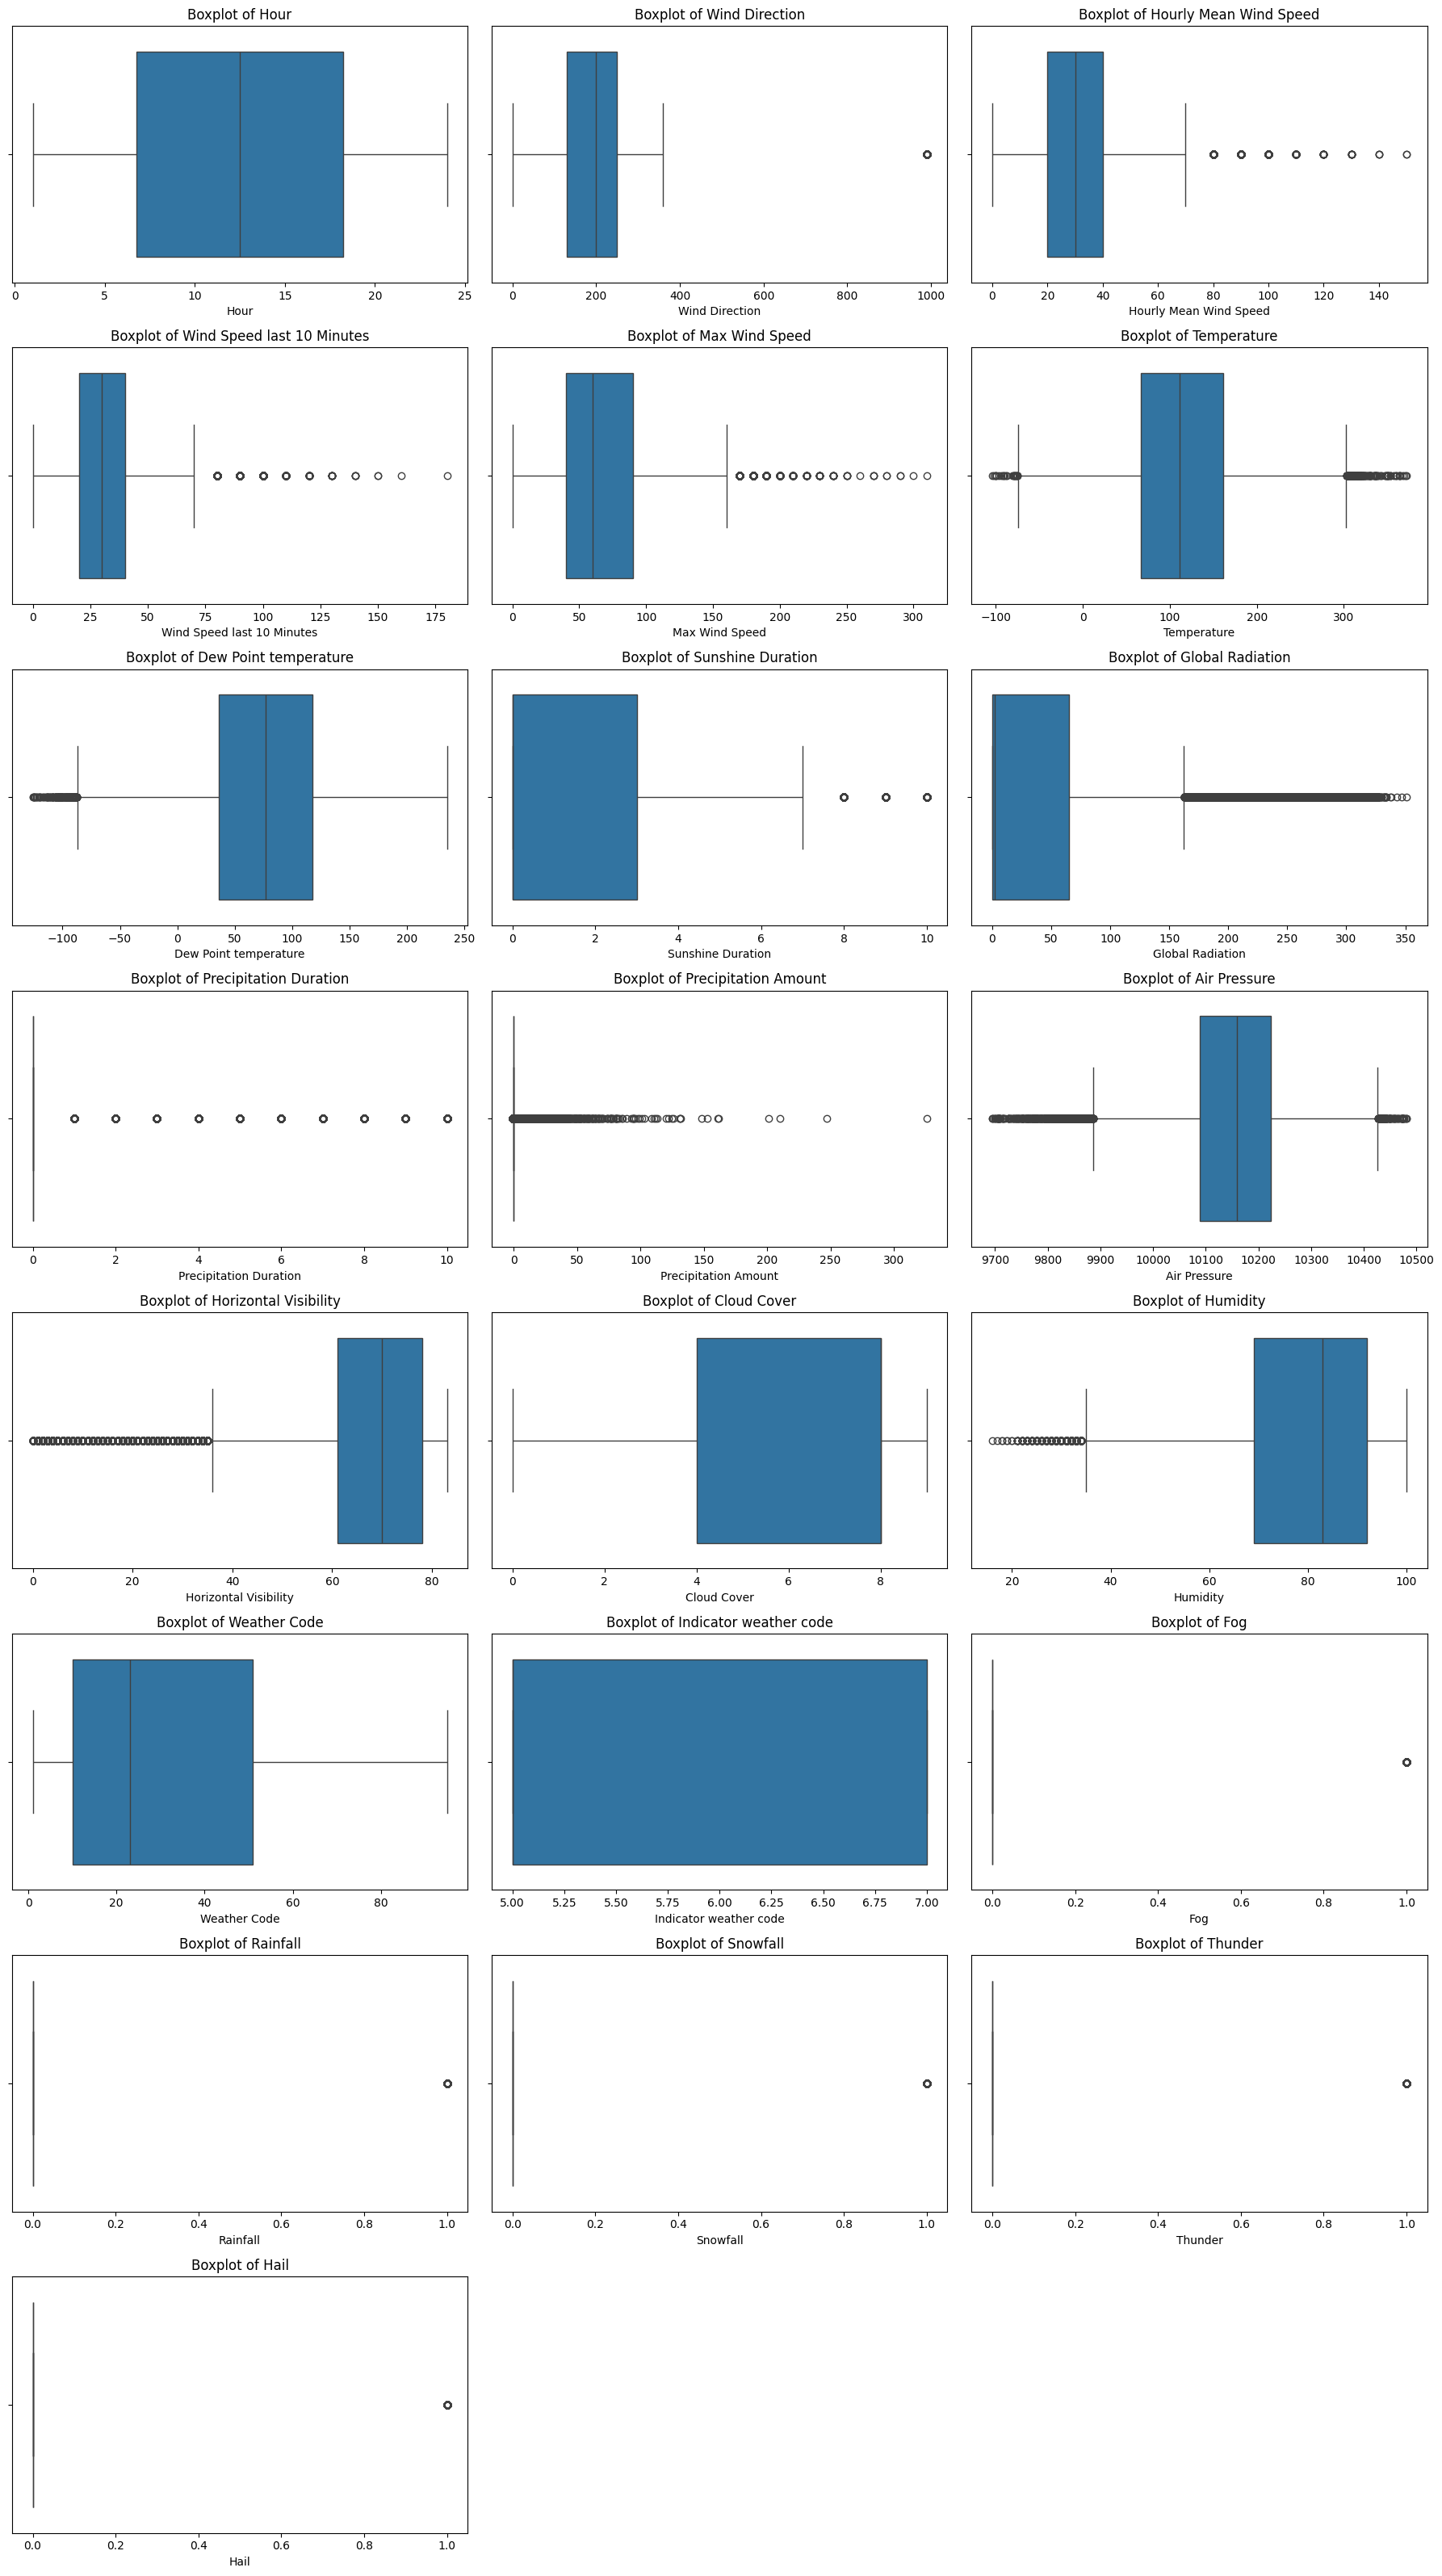

In [16]:
#boxplot: for outliers and data spread
num_cols = weather.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=weather[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

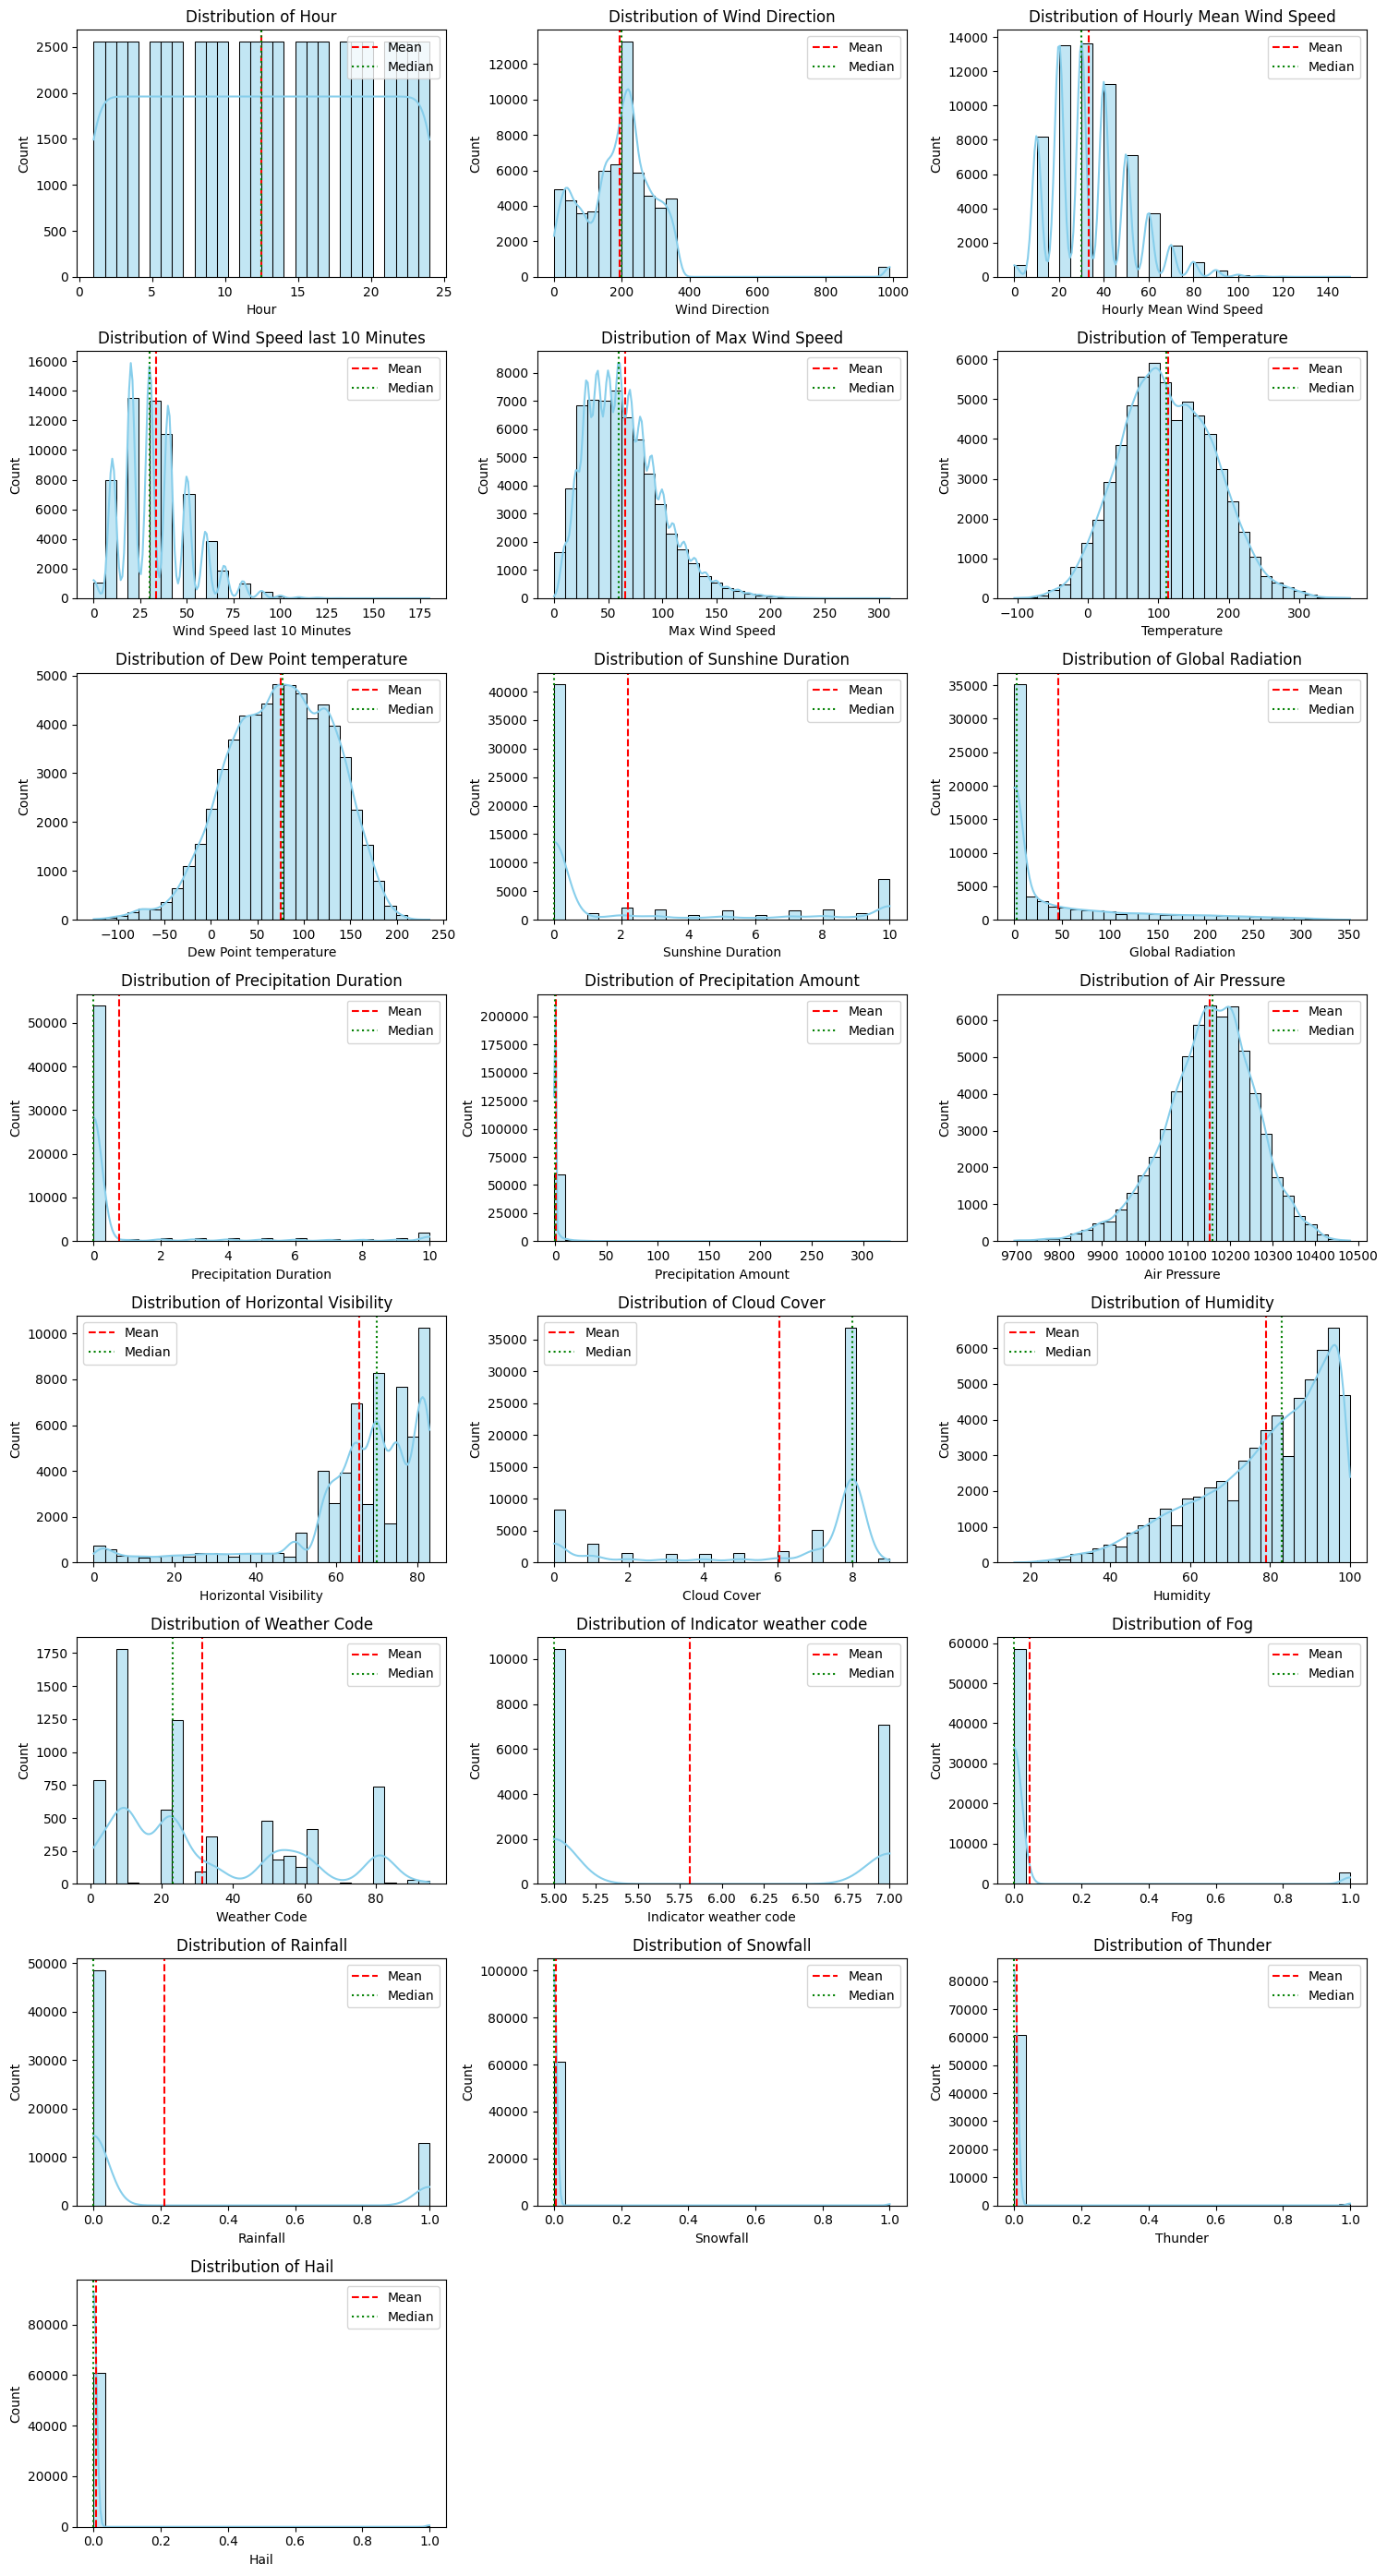

In [17]:
#histogram: for distribution and central tendency (mean, median)
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = weather[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    ax.axvline(data.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(data.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Preprocessing Weather: Bivariate

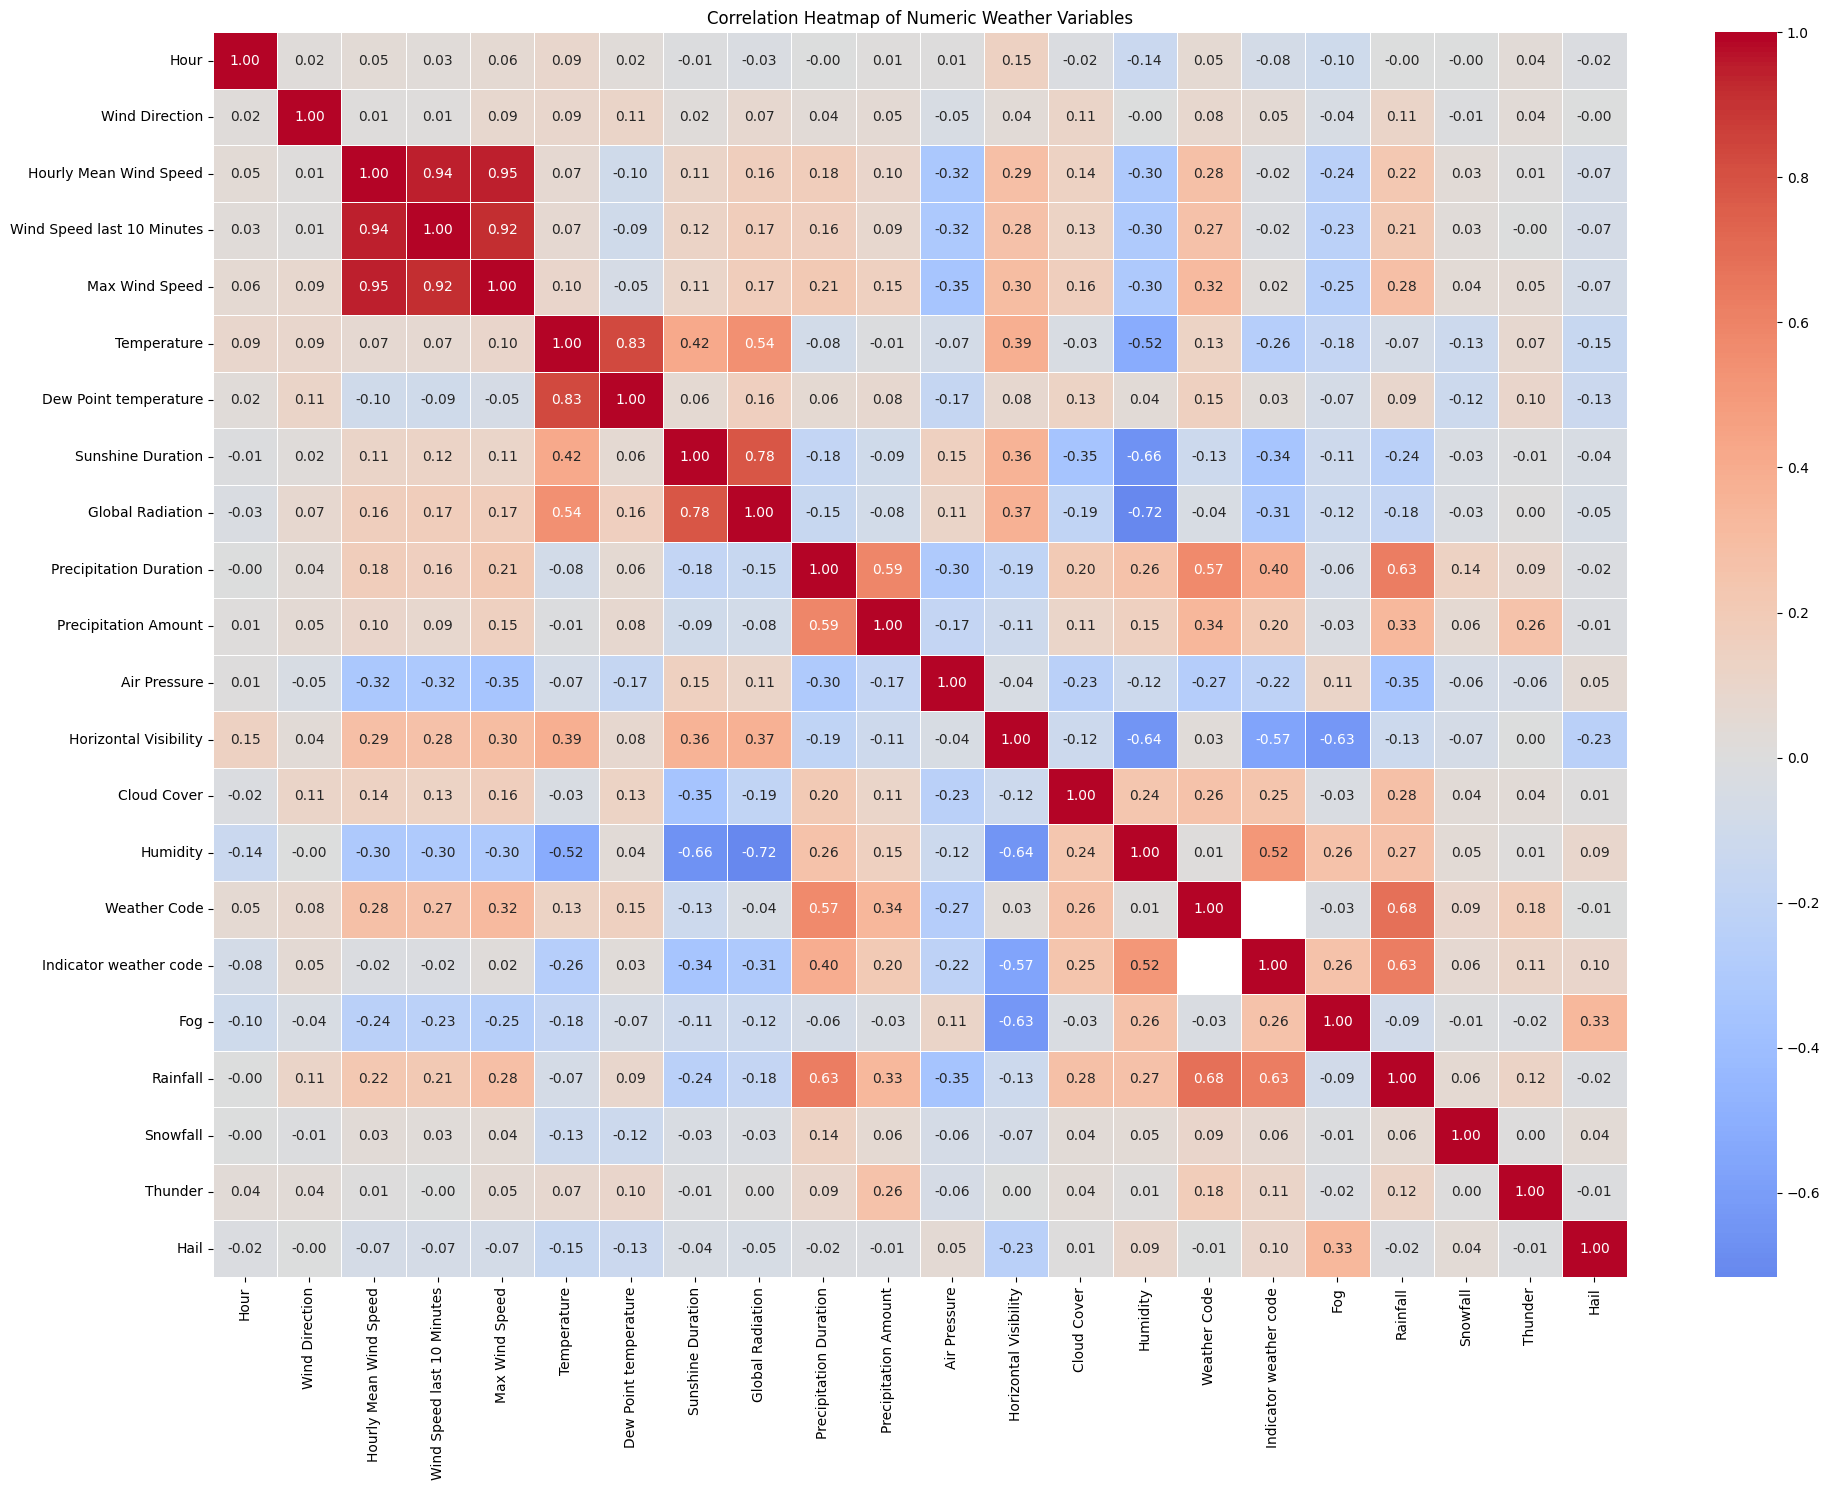

In [18]:
#heatmap: for correlation between numeric variables
corr = weather[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Weather Variables")
plt.tight_layout()
plt.show()

In [19]:
#check the top 10 most correlated pairs of numeric variables
corr_abs = weather[num_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(10)
print(top_pairs)

Hourly Mean Wind Speed      Max Wind Speed                0.947360
                            Wind Speed last 10 Minutes    0.941528
Wind Speed last 10 Minutes  Max Wind Speed                0.915844
Temperature                 Dew Point temperature         0.829017
Sunshine Duration           Global Radiation              0.782009
Global Radiation            Humidity                      0.716282
Weather Code                Rainfall                      0.683344
Sunshine Duration           Humidity                      0.663627
Horizontal Visibility       Humidity                      0.643103
                            Fog                           0.634408
dtype: float64


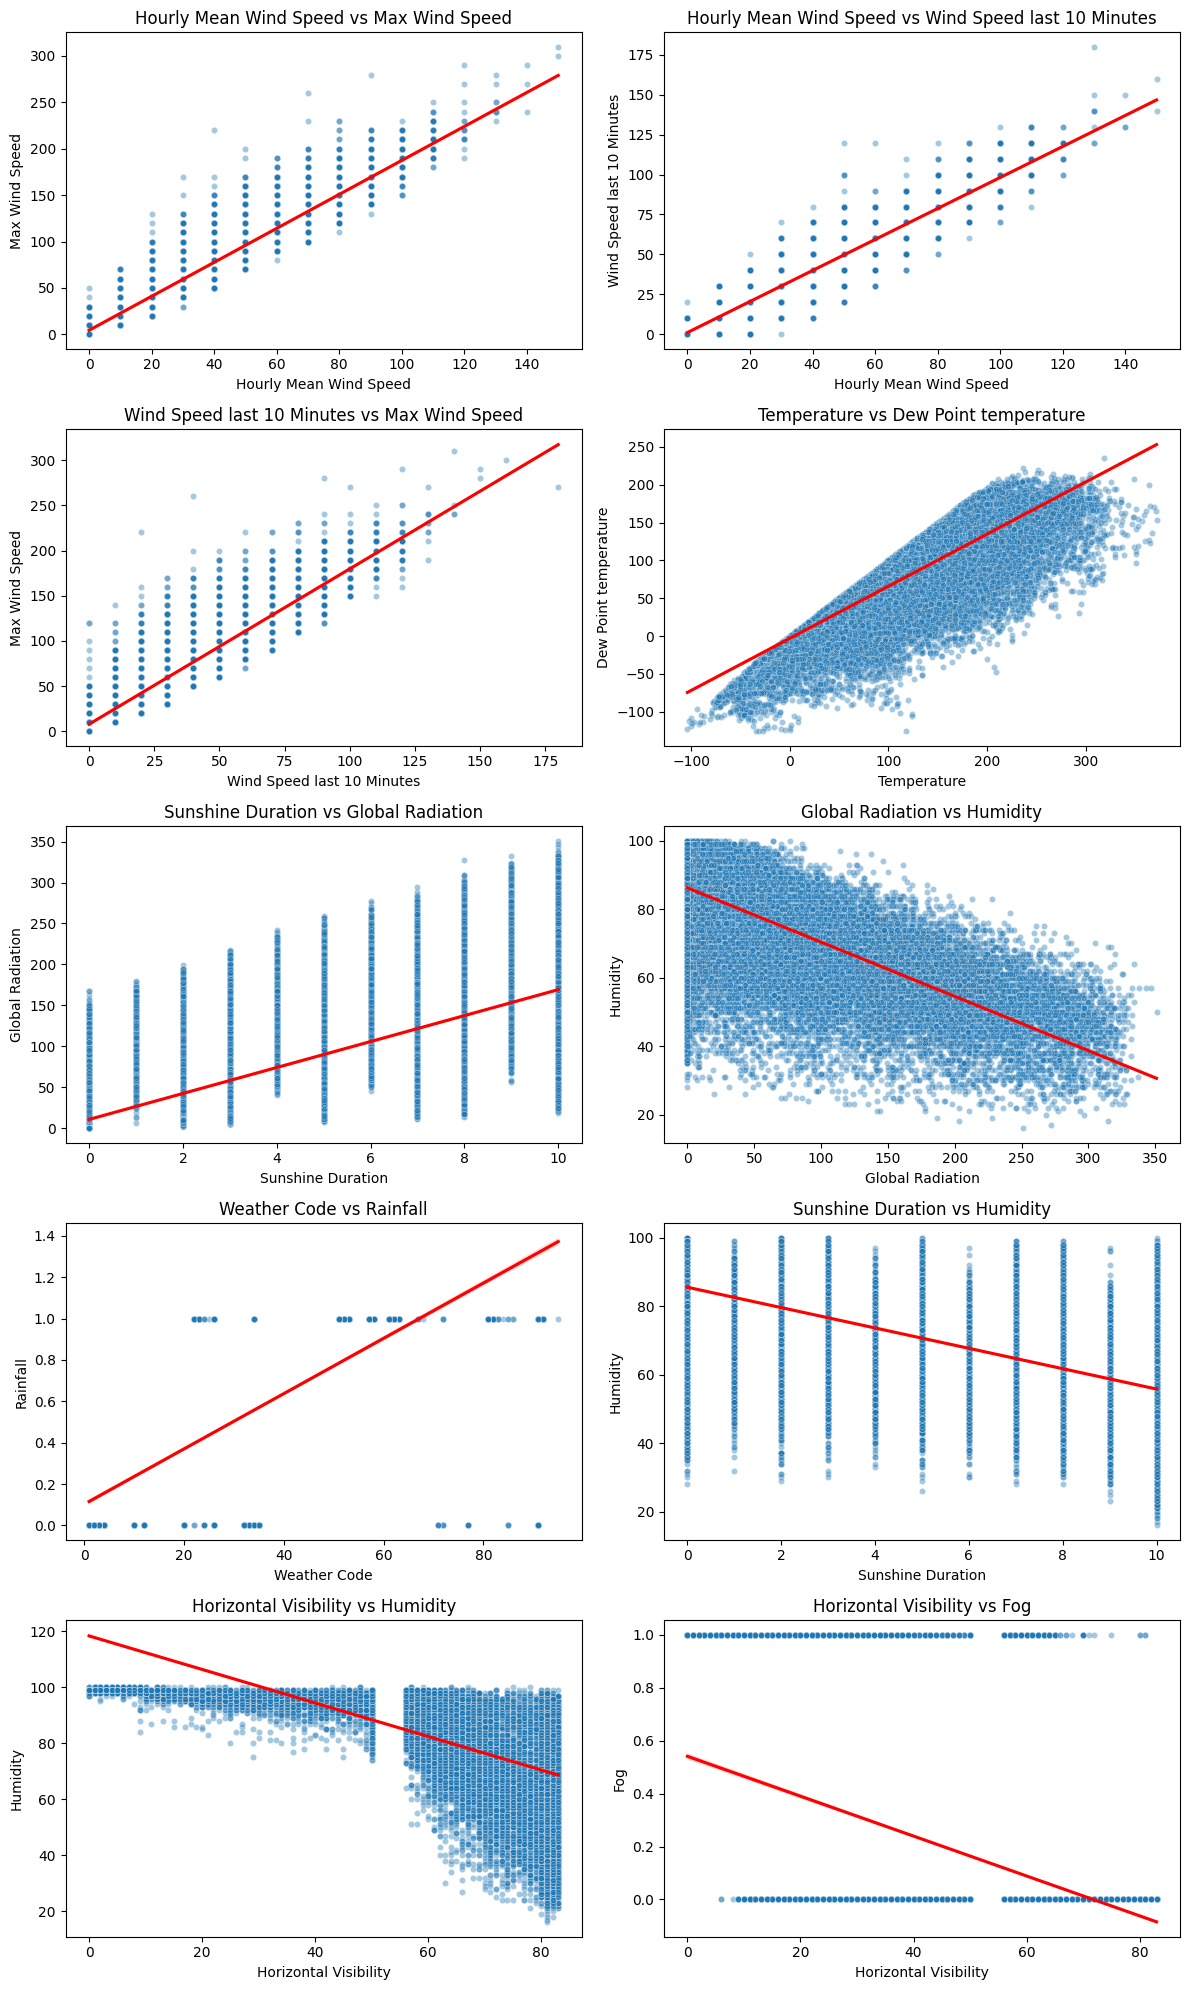

In [20]:
pairs = top_pairs.head(10).index.tolist()

n_pairs = len(pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=weather, x=x, y=y, alpha=0.4, s=20, ax=ax)
    sns.regplot(data=weather, x=x, y=y, scatter=False, color="red", ax=ax)
    ax.set_title(f"{x} vs {y}")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# EDA: Services

## Load in Data and quick Analysis

In [21]:
#Load in dataset services 2019-2022 (3m8s)
serv19 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2019.csv")
serv20 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2020.csv")
serv21 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2021.csv")
serv22 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2022.csv")


In [22]:
serv23 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2023.csv")
serv24 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2024.csv")
serv25 = pd.read_csv("I:/Datasets Thesis/Train Services 2019-2025/clean/services_clean_2025.csv")

In [23]:
#Concatenate dataset services as one (2m45s) 

df_train = pd.concat([serv19, serv20, serv21, serv22, serv23, serv24, serv25], ignore_index= True)
serv_col_names = df_train.columns
print( f" The column names of services are: {serv_col_names}" )

rows, columns = df_train.shape
print( f"df_train has Rows: {rows}, Columns: {columns}" ) #Rows: 38571, Columns: 14


 The column names of services are: Index(['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
       'Service:Train number', 'Service:Completely cancelled',
       'Service:Partly cancelled', 'Service:Maximum delay', 'Stop:RDT-ID',
       'Stop:Station code', 'Stop:Station name', 'Stop:Arrival time',
       'Stop:Arrival delay', 'Stop:Arrival cancelled', 'Stop:Departure time',
       'Stop:Departure delay', 'Stop:Departure cancelled',
       'Stop:Platform change', 'Stop:Planned platform',
       'Stop:Actual platform'],
      dtype='str')
df_train has Rows: 97558641, Columns: 20


In [24]:
df_train.head(10)

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,NaN,NaN,NaN,2019-01-01T02:00:00+01:00,1.0,False,True,3,2
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3
5,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220134,ASD,Amsterdam Centraal,2019-01-01T03:16:00+01:00,1.0,False,2019-01-01T03:19:00+01:00,0.0,False,False,2b,2b
6,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220142,UT,Utrecht Centraal,2019-01-01T03:54:00+01:00,0.0,False,NaN,NaN,NaN,False,5,5
7,738805,2019-01-01,Intercity,NS,1409,False,False,2,6220118,UT,Utrecht Centraal,NaN,NaN,NaN,2019-01-01T02:17:00+01:00,0.0,False,False,15,15
8,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,Amsterdam Bijlmer ArenA,2019-01-01T02:34:00+01:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6
9,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,Amsterdam Centraal,2019-01-01T02:44:00+01:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a


In [25]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 97558641 entries, 0 to 97558640
Data columns (total 20 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Service:RDT-ID                int64  
 1   Service:Date                  str    
 2   Service:Type                  str    
 3   Service:Company               str    
 4   Service:Train number          int64  
 5   Service:Completely cancelled  bool   
 6   Service:Partly cancelled      bool   
 7   Service:Maximum delay         int64  
 8   Stop:RDT-ID                   int64  
 9   Stop:Station code             str    
 10  Stop:Station name             str    
 11  Stop:Arrival time             str    
 12  Stop:Arrival delay            float64
 13  Stop:Arrival cancelled        object 
 14  Stop:Departure time           str    
 15  Stop:Departure delay          float64
 16  Stop:Departure cancelled      object 
 17  Stop:Platform change          bool   
 18  Stop:Planned platform         s

In [26]:
# Stop-level cancellation targets after filtering
print(df_train["Service:Completely cancelled"].value_counts(), "\n")
print(df_train["Service:Completely cancelled"].value_counts(normalize=True) * 100, "\n")

print(df_train["Service:Partly cancelled"].value_counts(), "\n")
print(df_train["Service:Partly cancelled"].value_counts(normalize=True) * 100)

Service:Completely cancelled
False    95432050
True      2126591
Name: count, dtype: int64 

Service:Completely cancelled
False    97.820192
True      2.179808
Name: proportion, dtype: float64 

Service:Partly cancelled
False    88133396
True      9425245
Name: count, dtype: int64 

Service:Partly cancelled
False    90.338893
True      9.661107
Name: proportion, dtype: float64


In [27]:
df_train["Service:Company"].value_counts()

Service:Company
NS    97558641
Name: count, dtype: int64

In [28]:
df_train["Service:Type"].value_counts()

Service:Type
Sprinter            63846551
Intercity           32398557
Intercity direct     1220335
Extra trein            93198
Name: count, dtype: int64

## Preprocessing Services: Analysis on Delay duration

In [29]:
df_train[["Service:Maximum delay"]].value_counts()

Service:Maximum delay
0                        90996511
1                         3053853
2                         1322720
3                          726271
4                          432445
                           ...   
1446                            1
183                             1
334                             1
292                             1
313                             1
Name: count, Length: 263, dtype: int64

In [30]:
# Define bins (adjust depending on your data distribution)
bins = [0, 5, 10, 30, 60, 120, np.inf]
labels = ["0–5 min", "6–10 min", "11–30 min", "31–60 min", "61–120 min", "120+ min"]

# Categorize
delay_bins = pd.cut(
    df_train["Service:Maximum delay"].dropna(),
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
delay_counts = delay_bins.value_counts().sort_index()

# Calculate percentages
delay_percentages = (delay_counts / delay_counts.sum()) * 100

# Create a DataFrame with both counts and percentages
delay_summary = pd.DataFrame({
    'Count': delay_counts,
    'Percentage': delay_percentages.round(4)
})

# Display
display(delay_summary)

,Count,Percentage
Service:Maximum delay,,
0–5 min,96811950,99.2346
6–10 min,487828,0.5000
11–30 min,240125,0.2461
31–60 min,16714,0.0171
61–120 min,1628,0.0017
120+ min,392,0.0004


In [31]:
# Filter rows where delay is greater than 121 minutes, sorted descending
long_delays = df_train[(df_train["Service:Maximum delay"] >121)].sort_values(
    "Service:Maximum delay", 
    ascending=False
)

# Display the rows
display(long_delays)

#highest delay is 999 minutes, which is around 16.65 hour

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
80777768,14650467,2024-10-23,Intercity,NS,29601,False,False,1446,132140774,ASD,Amsterdam Centraal,NaN,NaN,NaN,2024-10-22T05:59:00+02:00,1440.0,False,False,2b,2b
60375532,11044476,2023-04-19,Sprinter,NS,6384,False,False,1443,99410799,GVC,Den Haag Centraal,NaN,NaN,NaN,2023-04-19T01:19:00+02:00,1441.0,False,False,8,8
53088067,9751155,2022-09-29,Sprinter,NS,304615,False,False,1443,87665689,DRON,Dronten,NaN,NaN,NaN,2022-09-28T06:36:00+02:00,1440.0,False,False,4,4
53088064,9751154,2022-09-29,Sprinter,NS,304613,False,False,1441,87665686,DRON,Dronten,NaN,NaN,NaN,2022-09-28T06:06:00+02:00,1440.0,False,False,4,4
17504363,3676745,2020-03-24,Sprinter,NS,9079,False,False,1441,32286031,ZL,Zwolle,NaN,NaN,NaN,2020-03-23T22:48:00+01:00,1440.0,False,False,14,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74317671,13515670,2024-05-08,Intercity,NS,3112,False,True,123,121910601,UT,Utrecht Centraal,NaN,NaN,NaN,2024-05-08T05:56:00+02:00,0.0,False,False,7,7
7479594,1977400,2019-07-15,Intercity,NS,625,False,False,123,17021299,RTD,Rotterdam Centraal,NaN,NaN,NaN,2019-07-15T07:35:00+02:00,0.0,False,False,14,14
70463056,12838257,2024-01-22,Intercity,NS,303054,False,True,122,115734417,NM,Nijmegen,NaN,NaN,NaN,2024-01-22T15:43:00+01:00,0.0,True,False,NaN,NaN
7030326,1896569,2019-07-03,Sprinter,NS,15843,False,True,122,16372433,ASD,Amsterdam Centraal,NaN,NaN,NaN,2019-07-03T12:40:00+02:00,0.0,False,False,10b,10b


## Preprocessing Services: Missing Values

In [32]:
total_serv19 = df_train.isnull().sum().sort_values(ascending=False)
percent_serv19 = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data_serv19 = pd.concat([total_serv19, percent_serv19], axis=1, keys=['Total', 'Percent'])
missing_data_serv19

,Total,Percent
Stop:Departure cancelled,9416820,0.096525
Stop:Departure delay,9416820,0.096525
Stop:Departure time,9416820,0.096525
Stop:Arrival time,9414317,0.096499
Stop:Arrival cancelled,9414317,0.096499
Stop:Arrival delay,9414317,0.096499
Stop:Planned platform,5201966,0.053321
Stop:Actual platform,5201966,0.053321
Service:Company,0,0.000000
Service:Type,0,0.000000


In [33]:
# Rows where departure cancellation is missing
departure_null = df_train[df_train["Stop:Departure cancelled"].isna()].copy()

# Missingness flags
departure_null["departure_time_isna"] = departure_null["Stop:Departure time"].isna()
departure_null["departure_delay_isna"] = departure_null["Stop:Departure delay"].isna()

# Overview table
summary_departure_null = pd.crosstab(
    departure_null["departure_time_isna"],
    departure_null["departure_delay_isna"],
    margins=True
)
display(summary_departure_null)

# Explicit rule check: both must be NaN
rule_holds = (departure_null["departure_time_isna"] & departure_null["departure_delay_isna"]).all()
print("Rule holds:", rule_holds)

# Show counterexamples, if any
violations = departure_null[~(departure_null["departure_time_isna"] & departure_null["departure_delay_isna"])]
print("Violations:", len(violations))
if len(violations) > 0:
    display(violations.head(20))

departure_delay_isna,True,All
departure_time_isna,,
True,9416820,9416820
All,9416820,9416820


Rule holds: True
Violations: 0


In [34]:
# Rows where arrival cancellation is missing
arrival_null = df_train[df_train["Stop:Arrival cancelled"].isna()].copy()

# Missingness flags
arrival_null["arrival_time_isna"] = arrival_null["Stop:Arrival time"].isna()
arrival_null["arrival_delay_isna"] = arrival_null["Stop:Arrival delay"].isna()

# Overview table
summary_arrival_null = pd.crosstab(
    arrival_null["arrival_time_isna"],
    arrival_null["arrival_delay_isna"],
    margins=True
)
display(summary_arrival_null)

# Explicit rule check: both must be NaN
rule_holds = (arrival_null["arrival_time_isna"] & arrival_null["arrival_delay_isna"]).all()
print("Rule holds:", rule_holds)

# Show counterexamples, if any
violations = arrival_null[~(arrival_null["arrival_time_isna"] & arrival_null["arrival_delay_isna"])]
print("Violations:", len(violations))
if len(violations) > 0:
    display(violations.head(20))

arrival_delay_isna,True,All
arrival_time_isna,,
True,9414317,9414317
All,9414317,9414317


Rule holds: True
Violations: 0


In [35]:
# Check rows where planned platform is NaN or False
planned_col = df_train["Stop:Planned platform"]
actual_col = df_train["Stop:Actual platform"]

planned_is_false = planned_col.eq(False) | planned_col.astype(str).str.strip().str.lower().eq("false")
planned_is_na_or_false = planned_col.isna() | planned_is_false

planned_platform_null = df_train.loc[planned_is_na_or_false, ["Stop:Planned platform", "Stop:Actual platform"]].copy()

# Create boolean flags for missingness (without overwriting original columns)
planned_platform_null["planned_is_na"] = planned_platform_null["Stop:Planned platform"].isna()
planned_platform_null["actual_is_na"] = planned_platform_null["Stop:Actual platform"].isna()

# Summary: among rows where planned is NaN or False, is actual also NaN?
summary_planned_platform_null = pd.crosstab(
    planned_platform_null["planned_is_na"],
    planned_platform_null["actual_is_na"],
    margins=True
)

display(summary_planned_platform_null)

# Rows that do NOT satisfy "both planned and actual are NaN"
violations = planned_platform_null[
    ~(planned_platform_null["planned_is_na"] & planned_platform_null["actual_is_na"])
]

print(f"Rows checked (planned NaN or False): {len(planned_platform_null)}")
print(f"Rows where both planned and actual are NaN: {len(planned_platform_null) - len(violations)}")
print(f"Violations: {len(violations)}")

if len(violations) > 0:
    display(violations.head(20))

actual_is_na,True,All
planned_is_na,,
True,5201966,5201966
All,5201966,5201966


Rows checked (planned NaN or False): 5201966
Rows where both planned and actual are NaN: 5201966
Violations: 0


In [36]:
arr_cancel_na = df_train["Stop:Arrival cancelled"].isna()
dep_cancel_na = df_train["Stop:Departure cancelled"].isna()

# Explicit non-cancelled events
arr_valid = df_train["Stop:Arrival cancelled"].eq(False)
dep_valid = df_train["Stop:Departure cancelled"].eq(False)

# Start station:
# Arrival cancelled = NaN AND Departure cancelled = False
start_station_mask = arr_cancel_na & dep_valid

# End station:
# Departure cancelled = NaN AND Arrival cancelled = False
end_station_mask = dep_cancel_na & arr_valid

# Total missing values
total_arr_missing = arr_cancel_na.sum()
total_dep_missing = dep_cancel_na.sum()

# Counts matching assumption
start_count = start_station_mask.sum()
end_count = end_station_mask.sum()

# Percentages
start_pct = (start_count / total_arr_missing * 100) if total_arr_missing > 0 else 0
end_pct = (end_count / total_dep_missing * 100) if total_dep_missing > 0 else 0

# Summary table
summary = pd.DataFrame({
    "Missing values": [total_arr_missing, total_dep_missing],
    "Matches assumption": [start_count, end_count],
    "Percentage explained": [start_pct, end_pct]
}, index=[
    "Arrival cancelled NaN = Start stations",
    "Departure cancelled NaN = End stations"
])

display(summary)

# Check impossible overlap
print("Overlap between start and end stations:", 
      (start_station_mask & end_station_mask).sum())

,Missing values,Matches assumption,Percentage explained
Arrival cancelled NaN = Start stations,9414317,8875649,94.278204
Departure cancelled NaN = End stations,9416820,8873811,94.233627


Overlap between start and end stations: 0


In [37]:
# Create a subset of the DataFrame with only the cancellation-related columns
cancelled_columns = df_train[[
    "Stop:Arrival cancelled",
    "Stop:Departure cancelled",
    "Service:Partly cancelled",
    "Service:Completely cancelled"
 ]].copy()

# Group by the cancellation columns and count occurrences
cancelled_columns.groupby([
    "Stop:Arrival cancelled",  
    "Stop:Departure cancelled", 
    "Service:Partly cancelled", 
    "Service:Completely cancelled",], 
    dropna=False).size().reset_index(name='count')

,Stop:Arrival cancelled,Stop:Departure cancelled,Service:Partly cancelled,Service:Completely cancelled,count
0,NaN,False,False,False,8589935
1,NaN,False,False,True,3191
2,NaN,False,True,False,282130
3,NaN,False,True,True,393
4,NaN,NaN,False,False,4902
5,NaN,NaN,False,True,37
6,NaN,NaN,True,False,395
7,NaN,NaN,True,True,113
8,NaN,True,False,False,5513
9,NaN,True,False,True,3


In [38]:
# Create is_cancelled directly in this cell
arr = df_train["Stop:Arrival cancelled"]
dep = df_train["Stop:Departure cancelled"]
complete = df_train["Service:Completely cancelled"] if "Service:Completely cancelled" in df_train.columns else pd.Series(False, index=df_train.index)

df_train["is_cancelled"] = 1
not_cancelled_mask = (
    (complete == False) &
    (
        (arr.isna() & (dep == False)) |
        ((arr == False) & dep.isna()) |
        ((arr == False) & (dep == False))
    )
)
df_train.loc[not_cancelled_mask, "is_cancelled"] = 0

cancelled_columns["is_cancelled"] = df_train["is_cancelled"]

cancelled_columns.groupby([
    "Stop:Arrival cancelled", 
    "Stop:Departure cancelled", 
    "Service:Partly cancelled", 
    "Service:Completely cancelled",
    "is_cancelled"
], dropna=False).size().reset_index(name='count')

,Stop:Arrival cancelled,Stop:Departure cancelled,Service:Partly cancelled,Service:Completely cancelled,is_cancelled,count
0,NaN,False,False,False,0,8589935
1,NaN,False,False,True,1,3191
2,NaN,False,True,False,0,282130
3,NaN,False,True,True,1,393
4,NaN,NaN,False,False,1,4902
5,NaN,NaN,False,True,1,37
6,NaN,NaN,True,False,1,395
7,NaN,NaN,True,True,1,113
8,NaN,True,False,False,1,5513
9,NaN,True,False,True,1,3


In [39]:
vier = (df_train["Stop:Arrival cancelled"].isna() & 
        df_train["Stop:Departure cancelled"].isna() & 
        (df_train["Service:Partly cancelled"] == False) & 
        (df_train["Service:Completely cancelled"] == False))

df_train[vier].head(10)


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
38361190,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641409,HVS,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38509313,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870329,RTST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38519209,7248355,2021-09-22,Sprinter,NS,5186,False,False,0,64885345,RTST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38629051,7266297,2021-09-25,Sprinter,NS,5171,False,False,0,65054283,RTST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38638393,7268040,2021-09-25,Sprinter,NS,5186,False,False,0,65068996,RTST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38639674,7268332,2021-09-26,Intercity,NS,3016,False,False,0,65071110,SPTN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38639810,7268352,2021-09-26,Intercity,NS,3020,False,False,0,65071294,SPTN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38639827,7268354,2021-09-26,Intercity,NS,3014,False,False,0,65071311,SPTN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38640429,7268455,2021-09-26,Intercity,NS,3022,False,False,0,65072214,SPTN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38640494,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072287,SPTN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1


In [40]:
pd.set_option('display.max_columns', None)
df_train[df_train["Service:RDT-ID"] == 7222029]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
38361186,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641405,DT,Delft,NaN,NaN,NaN,2021-09-19T04:13:00+02:00,0.0,False,False,2,2,0
38361187,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641406,GV,Den Haag HS,2021-09-19T04:21:00+02:00,0.0,False,2021-09-19T04:23:00+02:00,0.0,False,False,6,6,0
38361188,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641407,LEDN,Leiden Centraal,2021-09-19T04:36:00+02:00,0.0,False,2021-09-19T04:45:00+02:00,0.0,False,False,5b,5b,0
38361189,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641408,ASD,Amsterdam Centraal,2021-09-19T05:17:00+02:00,0.0,False,2021-09-19T05:36:00+02:00,0.0,False,False,8b,8b,0
38361190,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641409,HVS,Hilversum,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38361191,7222029,2021-09-19,Intercity,NS,1418,False,False,0,64641410,UT,Utrecht Centraal,2021-09-19T06:21:00+02:00,0.0,False,NaN,NaN,NaN,True,7,8,0


In [41]:
df_train[df_train["Service:RDT-ID"] == 7246749]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
38509303,7246749,2021-09-22,Sprinter,NS,5171,False,False,1,64870319,GVC,Den Haag Centraal,NaN,NaN,NaN,2021-09-22T18:25:00+02:00,0.0,False,False,1,1,0
38509304,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870320,GV,Den Haag HS,2021-09-22T18:29:00+02:00,0.0,False,2021-09-22T18:29:00+02:00,0.0,False,False,3,3,0
38509305,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870321,GVMW,Den Haag Moerwijk,2021-09-22T18:32:00+02:00,0.0,False,2021-09-22T18:32:00+02:00,0.0,False,False,1,1,0
38509306,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870322,RSW,Rijswijk,2021-09-22T18:35:00+02:00,0.0,False,2021-09-22T18:35:00+02:00,0.0,False,False,1,1,0
38509307,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870323,DT,Delft,2021-09-22T18:39:00+02:00,0.0,False,2021-09-22T18:39:00+02:00,1.0,False,False,2,2,0
38509308,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870324,DTCP,Delft Campus,2021-09-22T18:42:00+02:00,1.0,False,2021-09-22T18:42:00+02:00,0.0,False,False,2,2,0
38509309,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870325,SDM,Schiedam Centrum,2021-09-22T18:49:00+02:00,0.0,False,2021-09-22T18:49:00+02:00,0.0,False,False,3,3,0
38509310,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870326,RTD,Rotterdam Centraal,2021-09-22T18:54:00+02:00,0.0,False,2021-09-22T18:56:00+02:00,0.0,False,False,7,7,0
38509311,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870327,RTB,Rotterdam Blaak,2021-09-22T18:59:00+02:00,0.0,False,2021-09-22T18:59:00+02:00,0.0,False,False,3,3,0
38509312,7246749,2021-09-22,Sprinter,NS,5171,False,False,0,64870328,RTZ,Rotterdam Zuid,2021-09-22T19:02:00+02:00,0.0,False,2021-09-22T19:02:00+02:00,0.0,False,False,3,3,0


In [42]:
df_train[df_train["Service:RDT-ID"] == 7268462]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
38640488,7268462,2021-09-26,Intercity,NS,3018,False,False,3,65072281,UT,Utrecht Centraal,NaN,NaN,NaN,2021-09-26T07:38:00+02:00,0.0,False,False,7,7,0
38640489,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072282,DVD,Duivendrecht,2021-09-26T07:55:00+02:00,1.0,False,2021-09-26T07:55:00+02:00,0.0,False,False,5,5,0
38640490,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072283,ASA,Amsterdam Amstel,2021-09-26T07:59:00+02:00,0.0,False,2021-09-26T07:59:00+02:00,1.0,False,False,1,1,0
38640491,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072284,ASD,Amsterdam Centraal,2021-09-26T08:06:00+02:00,1.0,False,2021-09-26T08:14:00+02:00,0.0,False,False,10a,10a,0
38640492,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072285,ASS,Amsterdam Sloterdijk,2021-09-26T08:19:00+02:00,0.0,False,2021-09-26T08:21:00+02:00,0.0,False,False,7,7,0
38640493,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072286,HLM,Haarlem,2021-09-26T08:33:00+02:00,0.0,False,2021-09-26T08:41:00+02:00,0.0,False,False,8,8,0
38640494,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072287,SPTN,Santpoort Noord,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38640495,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072288,CAS,Castricum,2021-09-26T09:04:00+02:00,0.0,False,2021-09-26T09:04:00+02:00,1.0,False,False,1,1,0
38640496,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072289,HLO,Heiloo,2021-09-26T09:10:00+02:00,0.0,False,2021-09-26T09:10:00+02:00,1.0,False,False,1,1,0
38640497,7268462,2021-09-26,Intercity,NS,3018,False,False,0,65072290,AMR,Alkmaar,2021-09-26T09:16:00+02:00,1.0,False,2021-09-26T09:19:00+02:00,1.0,False,False,2,2,0


In [43]:
zes = (df_train["Stop:Arrival cancelled"].isna() & 
        df_train["Stop:Departure cancelled"].isna() & 
        (df_train["Service:Partly cancelled"] == True) & 
        (df_train["Service:Completely cancelled"] == False))

df_train[zes].head(10)


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
38383621,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676401,CAS,Castricum,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38383622,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676402,HLO,Heiloo,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38572944,7256828,2021-09-21,Sprinter,NS,306640,False,True,0,64967054,NML,Nijmegen Lent,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
38653479,7271011,2021-09-26,Intercity,NS,3050,False,True,0,65092931,SPTN,Santpoort Noord,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
39162893,7355717,2021-10-06,Sprinter,NS,307435,False,True,0,65881353,ASS,Amsterdam Sloterdijk,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
39478325,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372587,ALMB,Almere Buiten,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
39635079,7434492,2021-10-18,Intercity,NS,308814,False,True,0,66615100,UT,Utrecht Centraal,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
39755773,7456124,2021-10-21,Sprinter,NS,304436,False,True,0,66807397,VG,Vught,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
40292141,7554386,2021-11-04,Sprinter,NS,305622,False,True,0,67666039,DLD,Den Dolder,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1
40292142,7554386,2021-11-04,Sprinter,NS,305622,False,True,0,67666040,BHV,Bilthoven,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1


In [44]:
df_train[df_train["Service:RDT-ID"] == 7226008]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
38383612,7226008,2021-09-16,Intercity,NS,303056,False,True,99,64676392,NM,Nijmegen,NaN,NaN,NaN,2021-09-16T16:13:00+02:00,0.0,True,False,NaN,NaN,1
38383613,7226008,2021-09-16,Intercity,NS,303056,False,True,1,64676393,AH,Arnhem Centraal,2021-09-16T16:26:00+02:00,0.0,True,2021-09-16T16:32:00+02:00,0.0,True,False,NaN,NaN,1
38383614,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676394,ED,Ede-Wageningen,2021-09-16T16:42:00+02:00,0.0,True,2021-09-16T16:42:00+02:00,0.0,True,False,NaN,NaN,1
38383615,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676395,KLP,Veenendaal-De Klomp,2021-09-16T16:48:00+02:00,0.0,True,2021-09-16T16:48:00+02:00,0.0,True,False,NaN,NaN,1
38383616,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676396,UT,Utrecht Centraal,2021-09-16T17:06:00+02:00,0.0,True,2021-09-16T17:08:00+02:00,0.0,True,False,NaN,NaN,1
38383617,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676397,ASA,Amsterdam Amstel,2021-09-16T17:27:00+02:00,0.0,True,2021-09-16T17:27:00+02:00,0.0,True,False,NaN,NaN,1
38383618,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676398,ASD,Amsterdam Centraal,2021-09-16T17:35:00+02:00,0.0,True,2021-09-16T17:39:00+02:00,0.0,True,False,NaN,NaN,1
38383619,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676399,ASS,Amsterdam Sloterdijk,2021-09-16T17:45:00+02:00,0.0,True,2021-09-16T17:45:00+02:00,99.0,False,False,4,4,1
38383620,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676400,ZD,Zaandam,2021-09-16T17:52:00+02:00,98.0,False,2021-09-16T17:52:00+02:00,98.0,False,True,1,2,0
38383621,7226008,2021-09-16,Intercity,NS,303056,False,True,0,64676401,CAS,Castricum,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,1


In [45]:
df_train[df_train["Service:RDT-ID"] == 7408614]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled
39478313,7408614,2021-10-14,Intercity,NS,302426,False,True,1,66372575,DDR,Dordrecht,NaN,NaN,NaN,2021-10-14T09:39:00+02:00,0.0,True,False,NaN,NaN,1
39478314,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372576,RTB,Rotterdam Blaak,2021-10-14T09:51:00+02:00,0.0,True,2021-10-14T09:51:00+02:00,0.0,True,False,NaN,NaN,1
39478315,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372577,RTD,Rotterdam Centraal,2021-10-14T09:54:00+02:00,0.0,True,2021-10-14T09:57:00+02:00,0.0,True,False,NaN,NaN,1
39478316,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372578,SDM,Schiedam Centrum,2021-10-14T10:01:00+02:00,0.0,True,2021-10-14T10:01:00+02:00,0.0,True,False,NaN,NaN,1
39478317,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372579,DT,Delft,2021-10-14T10:09:00+02:00,0.0,True,2021-10-14T10:09:00+02:00,0.0,True,False,NaN,NaN,1
39478318,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372580,GV,Den Haag HS,2021-10-14T10:16:00+02:00,0.0,True,2021-10-14T10:18:00+02:00,0.0,True,False,NaN,NaN,1
39478319,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372581,LAA,Den Haag Laan v NOI,2021-10-14T10:21:00+02:00,0.0,True,2021-10-14T10:21:00+02:00,0.0,True,False,NaN,NaN,1
39478320,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372582,LEDN,Leiden Centraal,2021-10-14T10:30:00+02:00,0.0,True,2021-10-14T10:31:00+02:00,0.0,True,False,NaN,NaN,1
39478321,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372583,SHL,Schiphol Airport,2021-10-14T10:46:00+02:00,0.0,True,2021-10-14T10:48:00+02:00,0.0,True,False,NaN,NaN,1
39478322,7408614,2021-10-14,Intercity,NS,302426,False,True,0,66372584,ASDZ,Amsterdam Zuid,2021-10-14T10:54:00+02:00,0.0,True,2021-10-14T10:56:00+02:00,0.0,False,True,1,2,1


## Data Visualization

Cancellation rate by year (%)


,year,cancel_rate_percentage
0,2019,3.08
1,2020,8.56
2,2021,4.85
3,2022,7.60
4,2023,5.88
5,2024,5.23
6,2025,6.96


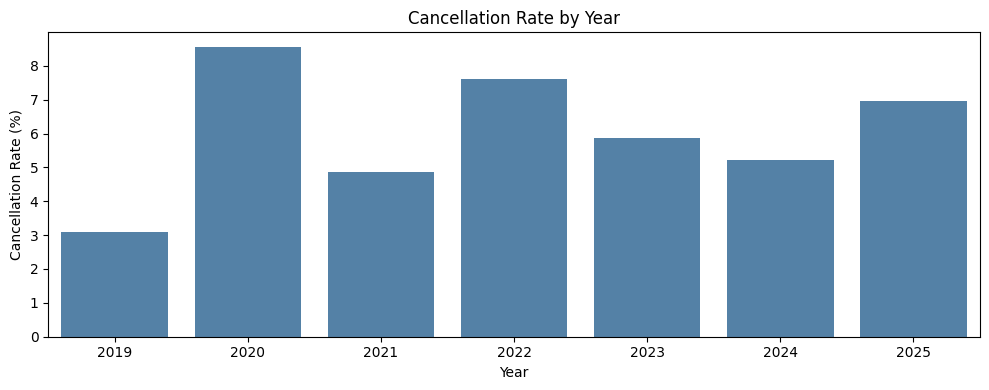


Cancellation rate by month (%)


,month,cancel_rate_percentage
0,1,4.92
1,2,7.16
2,3,5.94
3,4,8.58
4,5,6.73
5,6,6.62
6,7,4.83
7,8,5.37
8,9,5.94
9,10,5.36


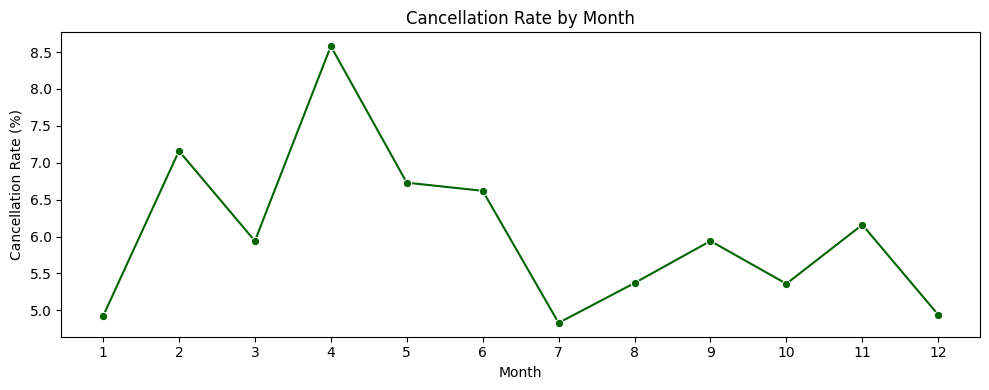


Cancellation rate by day of week (%)


,weekday,cancel_rate_percentage
1,Monday,6.27
5,Tuesday,6.94
6,Wednesday,6.17
4,Thursday,6.15
0,Friday,6.28
2,Saturday,4.99
3,Sunday,4.94


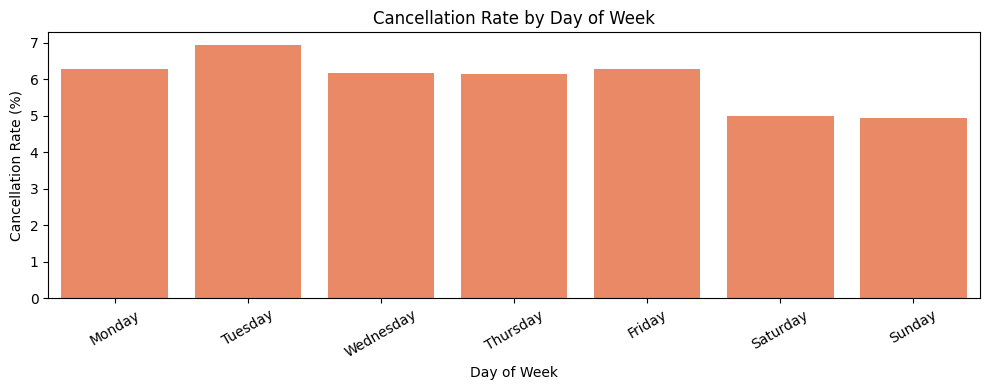


Cancellation rate by hour (%)


,hour,cancel_rate_percentage
0,0.0,4.27
1,1.0,7.79
2,2.0,7.01
3,3.0,4.19
4,4.0,4.80
5,5.0,5.32
6,6.0,5.82
7,7.0,6.11
8,8.0,6.21
9,9.0,6.26


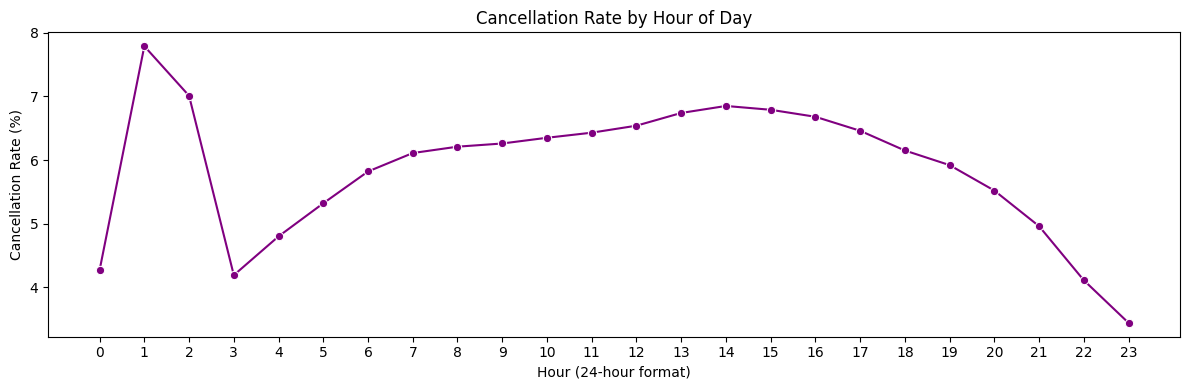

In [46]:
# Cancellation Rate Analysis by Year, Month, Day of Week, and Hour
df_time = df_train.copy()
df_time["Service:Date"] = pd.to_datetime(df_time["Service:Date"], errors="coerce")
df_time = df_time.dropna(subset=["Service:Date"])

df_time["year"] = df_time["Service:Date"].dt.year
df_time["month"] = df_time["Service:Date"].dt.month
df_time["weekday"] = df_time["Service:Date"].dt.day_name()

# Extract hour from departure time
if "Stop:Departure time" in df_time.columns:
    dep_time_utc = pd.to_datetime(df_time["Stop:Departure time"], errors="coerce", utc=True)
    df_time["hour"] = dep_time_utc.dt.hour
else:
    df_time["hour"] = pd.NA

# Cancellation rate by year
rate_year = df_time.groupby("year")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage")
print("Cancellation rate by year (%)")
display(rate_year)

plt.figure(figsize=(10, 4))
sns.barplot(data=rate_year, x="year", y="cancel_rate_percentage", color="steelblue")
plt.title("Cancellation Rate by Year")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# Cancellation rate by month
rate_month = df_time.groupby("month")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage").sort_values("month")
print("\nCancellation rate by month (%)")
display(rate_month)

plt.figure(figsize=(10, 4))
sns.lineplot(data=rate_month, x="month", y="cancel_rate_percentage", marker="o", color="darkgreen")
plt.title("Cancellation Rate by Month")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Cancellation rate by day of week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
rate_weekday = df_time.groupby("weekday")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage")
rate_weekday["weekday"] = pd.Categorical(rate_weekday["weekday"], categories=weekday_order, ordered=True)
rate_weekday = rate_weekday.sort_values("weekday")
print("\nCancellation rate by day of week (%)")
display(rate_weekday)

plt.figure(figsize=(10, 4))
sns.barplot(data=rate_weekday, x="weekday", y="cancel_rate_percentage", color="coral")
plt.title("Cancellation Rate by Day of Week")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Cancellation rate by hour
hour_data = df_time.dropna(subset=["hour"])
if len(hour_data) > 0:
    rate_hour = hour_data.groupby("hour")["is_cancelled"].mean().mul(100).round(2).reset_index(name="cancel_rate_percentage")
    print("\nCancellation rate by hour (%)")
    display(rate_hour)

    plt.figure(figsize=(12, 4))
    sns.lineplot(data=rate_hour, x="hour", y="cancel_rate_percentage", marker="o", color="purple")
    plt.title("Cancellation Rate by Hour of Day")
    plt.ylabel("Cancellation Rate (%)")
    plt.xlabel("Hour (24-hour format)")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

Top 10 stations by number of cancellations


,Stop:Station name,cancel_count,total_stops,cancel_rate_pct
258,Utrecht Centraal,208972,3093437,6.76
23,Amsterdam Centraal,208689,2838925,7.35
226,Rotterdam Centraal,167625,1770146,9.47
238,Schiphol Airport,152874,1953038,7.83
29,Amsterdam Sloterdijk,132632,2076715,6.39
175,Leiden Centraal,116327,1505776,7.73
81,Den Haag Centraal,112927,1673633,6.75
0,'s-Hertogenbosch,111009,1247882,8.90
30,Amsterdam Zuid,91173,1098447,8.30
108,Eindhoven Centraal,90032,996864,9.03


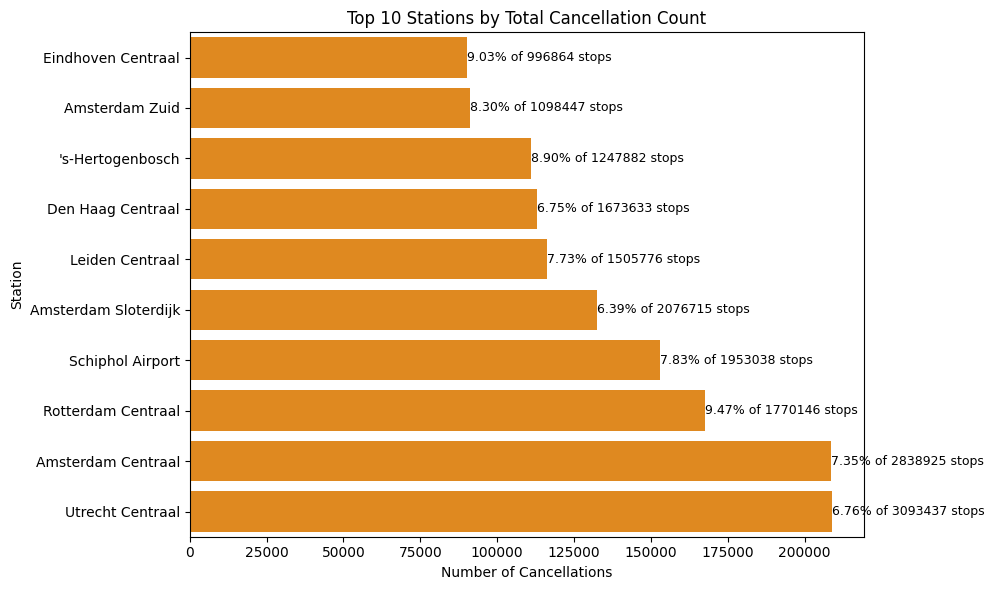

In [47]:

# Build a summary with cancellation at station level, sorted by total cancellations

# Calculate cancellation count and total stops per station
rate_station = (
    df_time.groupby("Stop:Station name")["is_cancelled"]
    .agg(cancel_count="sum", total_stops="count")
    .assign(cancel_rate_pct=lambda x: ((x["cancel_count"] / x["total_stops"]) * 100).round(2))
    .reset_index()
    .sort_values("cancel_count", ascending=False)
)

# Display the top 10 stations by cancellation count
print("Top 10 stations by number of cancellations")
display(rate_station.head(10))

top10 = rate_station.head(10).sort_values("cancel_count", ascending=True)  # ascending for horizontal bar readability

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, y="Stop:Station name", x="cancel_count", color="darkorange", ax=ax)

# Add rate label at the end of each bar
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row["cancel_count"] + 10,
        i,
        f"{row['cancel_rate_pct']:.2f}% of {int(row['total_stops'])} stops",
        va="center",
        fontsize=9
    )

ax.set_title("Top 10 Stations by Total Cancellation Count")
ax.set_xlabel("Number of Cancellations")
ax.set_ylabel("Station")
plt.tight_layout()
plt.show()


Cancellation rate by service type (%)


,Service:Type,cancel_rate_pct
2,Intercity direct,13.044943
1,Intercity,9.125644
0,Extra trein,5.667504
3,Sprinter,4.328181


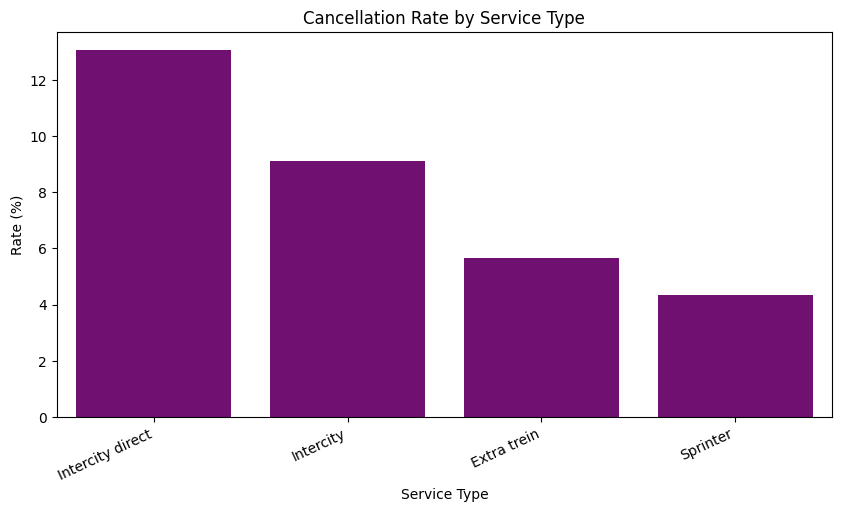

In [48]:
# Cancellation rate by service type
rate_type = (
df_time.groupby("Service:Type")["is_cancelled"]
.mean()
.mul(100)
.reset_index(name="cancel_rate_pct")
.sort_values("cancel_rate_pct", ascending=False)
)

print("Cancellation rate by service type (%)")
display(rate_type)

plt.figure(figsize=(10, 5))
sns.barplot(data=rate_type, x="Service:Type", y="cancel_rate_pct", color="purple")
plt.title("Cancellation Rate by Service Type")
plt.ylabel("Rate (%)")
plt.xlabel("Service Type")
plt.xticks(rotation=25, ha="right")
plt.show()

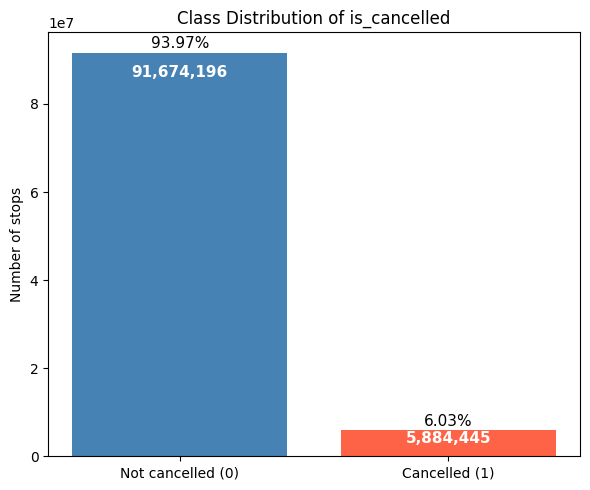

In [49]:
counts = df_time["is_cancelled"].value_counts().sort_index()
total  = len(df_time)

num_not_cancelled = counts.get(0, 0)
num_cancelled     = counts.get(1, 0)
pct_cancelled     = num_cancelled / total * 100
imbalance_ratio   = num_not_cancelled / num_cancelled if num_cancelled > 0 else float("inf")

# Bar chart
class_labels = ["Not cancelled (0)", "Cancelled (1)"]
class_counts  = [num_not_cancelled, num_cancelled]
class_pcts    = [round(100 - pct_cancelled, 2), round(pct_cancelled, 2)]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(class_labels, class_counts, color=["steelblue", "tomato"])

for bar, count, pct in zip(bars, class_counts, class_pcts):
    # Show count inside the bar (near top)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.97,
        f"{count:,}",
        ha="center", va="top", fontsize=11, color="white", fontweight="bold"
    )
    # Show percentage just above the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.003,
        f"{pct:.2f}%",
        ha="center", va="bottom", fontsize=11
    )

ax.set_title("Class Distribution of is_cancelled")
ax.set_ylabel("Number of stops")
plt.tight_layout()
plt.show()

# Combine Dataset

In [50]:
# Add hour column to df_train using departure time, then arrival time as fallback
dep_time = pd.to_datetime(df_train["Stop:Departure time"], errors="coerce", utc=True)
arr_time = pd.to_datetime(df_train["Stop:Arrival time"], errors="coerce", utc=True)

# Prefer departure hour; if missing, use arrival hour
df_train["Hour"] = dep_time.dt.hour.fillna(arr_time.dt.hour).astype("Int64")

# Remap midnight from 0 to 24 so hour range is 1..24
df_train.loc[df_train["Hour"] == 0, "Hour"] = 24

# Forward-fill any remaining NaN hours (e.g., for rows where both departure and arrival times are missing)
df_train['Hour'] = df_train['Hour'].ffill()

# Quick check
print(df_train["Hour"].value_counts(dropna=False).sort_index())

Hour
1       65872
2       59102
3      725914
4     2712862
5     4574288
6     5358563
7     5520953
8     5450260
9     5413985
10    5426565
11    5431484
12    5435337
13    5497526
14    5630885
15    5712417
16    5689251
17    5506728
18    5081185
19    4641043
20    4370550
21    4089239
22    3336922
23    1538251
24     289459
Name: count, dtype: Int64


In [53]:
# Merge weather into df_train using shared date and hour keys
df_train["YYYYMMDD"] = pd.to_datetime(df_train["Service:Date"], errors="coerce").dt.normalize()
df_train["Hour"] = pd.to_numeric(df_train["Hour"], errors="coerce").astype("Int64")

weather_join = weather.rename(columns={"Date": "YYYYMMDD"}).copy()
weather_join["YYYYMMDD"] = pd.to_datetime(weather_join["YYYYMMDD"], errors="coerce").dt.normalize()
weather_join["Hour"] = pd.to_numeric(weather_join["Hour"], errors="coerce").astype("Int64")

# Keep one weather row per date-hour before merging
weather_join = weather_join.drop_duplicates(subset=["YYYYMMDD", "Hour"])

comb = df_train.merge(
    weather_join,
    on=["YYYYMMDD", "Hour"],
    how="left",
    suffixes=("", "_weather")
)

print(comb.shape)
display(comb.head())

(97558641, 44)


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,is_cancelled,Hour,YYYYMMDD,Wind Direction,Hourly Mean Wind Speed,Wind Speed last 10 Minutes,Max Wind Speed,Temperature,Dew Point temperature,Sunshine Duration,Global Radiation,Precipitation Duration,Precipitation Amount,Air Pressure,Horizontal Visibility,Cloud Cover,Humidity,Weather Code,Indicator weather code,Fog,Rainfall,Snowfall,Thunder,Hail
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,NaN,NaN,NaN,2019-01-01T02:00:00+01:00,1.0,False,True,3,2,0,1,2019-01-01,230,30,20,60,79,63,0,0,0,0,10309,36,8.0,89,10.0,7.0,0,0,0,0,0
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1,0,1,2019-01-01,230,30,20,60,79,63,0,0,0,0,10309,36,8.0,89,10.0,7.0,0,0,0,0,0
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6,0,1,2019-01-01,230,30,20,60,79,63,0,0,0,0,10309,36,8.0,89,10.0,7.0,0,0,0,0,0
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b,0,1,2019-01-01,230,30,20,60,79,63,0,0,0,0,10309,36,8.0,89,10.0,7.0,0,0,0,0,0
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3,0,2,2019-01-01,250,30,30,70,84,56,0,0,0,0,10306,41,8.0,82,10.0,7.0,0,0,0,0,0
